In [9]:
from google.colab import files
uploaded = files.upload()

Saving content.jpg to content.jpg
Saving style.jpg to style.jpg


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import copy

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
imsize = 512 if torch.cuda.is_available() else 128

loader = transforms.Compose([
    transforms.Resize((imsize, imsize)),
    transforms.ToTensor()
])

def load_image(path):
    image = Image.open(path)
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)


In [11]:
content_img = load_image("content.jpg")
style_img = load_image("style.jpg")

In [12]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad = False

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:08<00:00, 67.1MB/s]


In [13]:
content_layers = ['conv_4']
style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

In [14]:
def get_features(image, model):
    layers = {
        '0': 'conv_1',
        '5': 'conv_2',
        '10': 'conv_3',
        '19': 'conv_4',
        '28': 'conv_5'
    }

    features = {}
    x = image

    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x

    return features

In [15]:
def gram_matrix(tensor):
    b, c, h, w = tensor.size()
    tensor = tensor.view(c, h*w)
    gram = torch.mm(tensor, tensor.t())
    return gram

In [16]:
content_features = get_features(content_img, vgg)
style_features = get_features(style_img, vgg)

style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

In [17]:
target = content_img.clone().requires_grad_(True).to(device)

In [18]:
optimizer = optim.Adam([target], lr=0.003)

In [19]:
steps = 3000
style_weight = 1e6
content_weight = 1

for i in range(steps):

    target_features = get_features(target, vgg)

    # Content Loss
    content_loss = torch.mean((target_features['conv_4'] - content_features['conv_4'])**2)

    # Style Loss
    style_loss = 0
    for layer in style_layers:
        target_gram = gram_matrix(target_features[layer])
        style_gram = style_grams[layer]

        _, c, h, w = target_features[layer].shape

        layer_style_loss = torch.mean((target_gram - style_gram)**2)
        style_loss += layer_style_loss / (c*h*w)

    total_loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if i % 500 == 0:
        print(f"Step {i}, Total Loss: {total_loss.item()}")

Step 0, Total Loss: 47958220.0
Step 500, Total Loss: 587578.0
Step 1000, Total Loss: 180671.484375
Step 1500, Total Loss: 124605.9140625
Step 2000, Total Loss: 101161.875
Step 2500, Total Loss: 87344.71875


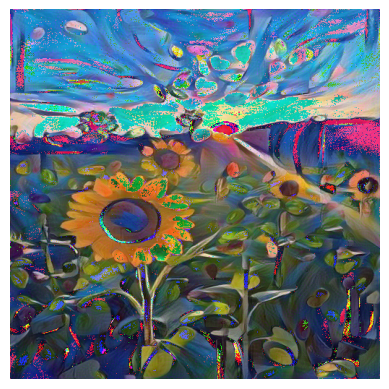

In [20]:
def imshow(tensor):
    image = tensor.cpu().clone()
    image = image.squeeze(0)
    image = transforms.ToPILImage()(image)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

imshow(target)